In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training Images Shape:", x_train.shape)
print("Testing Images Shape :", x_test.shape)

x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

input_sample = x_train_norm[0:1]  # used for the analytical questions below
print("x_train_norm shape:", x_train_norm.shape)
print("y_train_cat shape :", y_train_cat.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2732s 16us/step
Training Images Shape: (50000, 32, 32, 3)
Testing Images Shape : (10000, 32, 32, 3)
x_train_norm shape: (50000, 32, 32, 3)
y_train_cat shape : (50000, 10)


In [3]:
def conv_output_size(W, K, P, S):
    return (W + 2 * P - K) // S + 1

W, K, P, S = 64, 5, 2, 2
out_size = conv_output_size(W, K, P, S)
print(f"Analytical formula -> Output size: {out_size} x {out_size}")

# Verify with an actual Keras layer using explicit zero-padding + 'valid' convolution
dummy_input = tf.random.normal((1, 64, 64, 3))
padded = layers.ZeroPadding2D(padding=P)(dummy_input)
conv = layers.Conv2D(filters=8, kernel_size=K, strides=S, padding='valid')
verified_output = conv(padded)
print("Keras-verified output shape:", verified_output.shape)

Analytical formula -> Output size: 32 x 32


I0000 00:00:1786012386.454650      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786012386.457394      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Keras-verified output shape: (1, 32, 32, 8)


In [4]:
def conv_param_count(kh, kw, in_channels, filters, use_bias=True):
    bias_term = 1 if use_bias else 0
    return (kh * kw * in_channels + bias_term) * filters

manual_params = conv_param_count(3, 3, 3, 64)
print(f"Analytical formula -> Trainable parameters: {manual_params}")

# Verify with an actual Keras layer
verify_model = models.Sequential([
    layers.Conv2D(64, (3, 3), padding='same', input_shape=(32, 32, 3))
])
verify_model.summary()
print("Keras-reported params for the Conv2D layer:", verify_model.layers[0].count_params())

Analytical formula -> Trainable parameters: 1792


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,792 (7.00 KB)

 Trainable params: 1,792 (7.00 KB)

 Non-trainable params: 0 (0.00 B)

Keras-reported params for the Conv2D layer: 1792



--- Training with RELU activation ---
Epoch 1/5
 44/141 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1660 - loss: 2.2130

I0000 00:00:1786012395.179166      71 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.3264 - loss: 1.8514 - val_accuracy: 0.4140 - val_loss: 1.5908
Epoch 2/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4646 - loss: 1.4936 - val_accuracy: 0.4880 - val_loss: 1.4106
Epoch 3/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5398 - loss: 1.3136 - val_accuracy: 0.4970 - val_loss: 1.3422
Epoch 4/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5863 - loss: 1.1829 - val_accuracy: 0.5330 - val_loss: 1.2729
Epoch 5/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6271 - loss: 1.0798 - val_accuracy: 0.5730 - val_loss: 1.2145
RELU -> Test Accuracy: 0.5705 | Training Time: 9.1s

--- Training with SIGMOID activation ---
Epoch 1/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.1060 - loss: 2.3506 - val_accuracy: 0.0860 - val_loss: 2.3103
Epoch 2/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1052 - loss: 2.3082 - val_accuracy: 0.0860 - val_loss: 2.3064
Epoch 3/5
141/141 ━━━━━━━

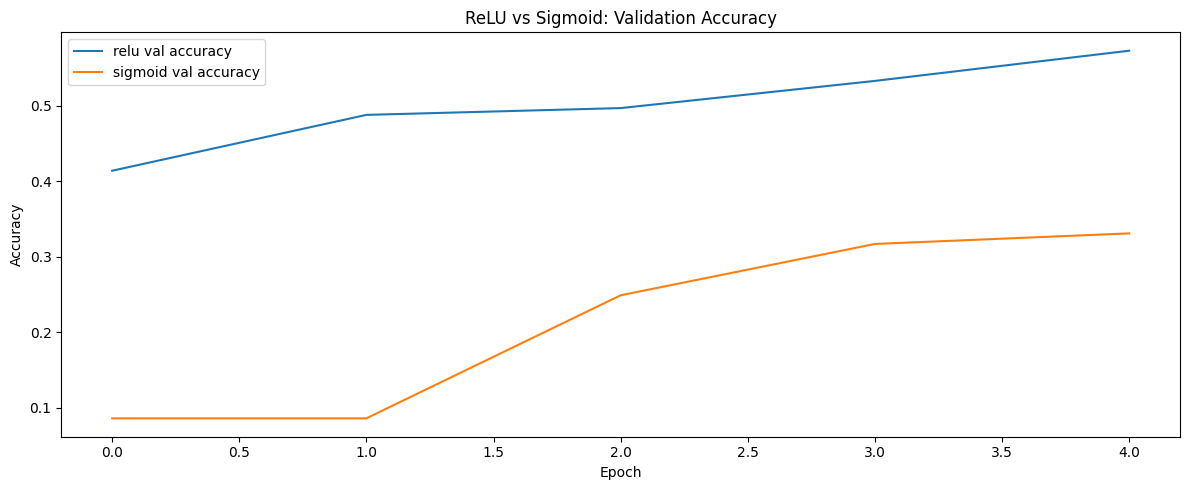

In [5]:
def build_activation_model(activation='relu'):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), padding='same', activation=activation, input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), padding='same', activation=activation),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation=activation),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Use a subset for a quick, fair comparison
subset_size = 10000
x_sub, y_sub = x_train_norm[:subset_size], y_train_cat[:subset_size]

activation_histories = {}
activation_times = {}

for act in ['relu', 'sigmoid']:
    print(f"\n--- Training with {act.upper()} activation ---")
    act_model = build_activation_model(act)
    start = time.time()
    hist = act_model.fit(x_sub, y_sub, epochs=5, batch_size=64,
                          validation_split=0.1, verbose=1)
    elapsed = time.time() - start
    activation_histories[act] = hist
    activation_times[act] = elapsed
    test_loss, test_acc = act_model.evaluate(x_test_norm, y_test_cat, verbose=0)
    print(f"{act.upper()} -> Test Accuracy: {test_acc:.4f} | Training Time: {elapsed:.1f}s")

plt.figure(figsize=(12, 5))
for act in ['relu', 'sigmoid']:
    plt.plot(activation_histories[act].history['val_accuracy'], label=f'{act} val accuracy')
plt.title('ReLU vs Sigmoid: Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## Question 4: Max Pooling vs Average Pooling
Two identical CNNs are trained, one using MaxPooling2D and one using AveragePooling2D, to compare test accuracy. Max pooling typically preserves the strongest activations (edges/textures) and tends to slightly outperform average pooling for image classification.

In [6]:
def build_pooling_model(pooling_type='max'):
    model = models.Sequential()
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
    model.add(layers.MaxPooling2D((2, 2)) if pooling_type == 'max' else layers.AveragePooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)) if pooling_type == 'max' else layers.AveragePooling2D((2, 2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

pooling_results = {}
pooling_times = {}

for pool_type in ['max', 'average']:
    print(f"\n--- Training with {pool_type.upper()} Pooling ---")
    pmodel = build_pooling_model(pool_type)
    start = time.time()
    pmodel.fit(x_train_norm, y_train_cat, epochs=5, batch_size=64,
               validation_split=0.1, verbose=1)
    elapsed = time.time() - start
    test_loss, test_acc = pmodel.evaluate(x_test_norm, y_test_cat, verbose=0)
    pooling_results[pool_type] = test_acc
    pooling_times[pool_type] = elapsed
    print(f"{pool_type.upper()} Pooling -> Test Accuracy: {test_acc:.4f} | Training Time: {elapsed:.1f}s")

print("\nPooling Comparison Summary:")
for k in pooling_results:
    print(f"{k.capitalize():8s} Pooling | Accuracy: {pooling_results[k]:.4f} | Time: {pooling_times[k]:.1f}s")


--- Training with MAX Pooling ---
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.4608 - loss: 1.5108 - val_accuracy: 0.5584 - val_loss: 1.2508
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6054 - loss: 1.1248 - val_accuracy: 0.6432 - val_loss: 1.0425
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6607 - loss: 0.9776 - val_accuracy: 0.6710 - val_loss: 0.9675
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6936 - loss: 0.8861 - val_accuracy: 0.6888 - val_loss: 0.9160
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7176 - loss: 0.8188 - val_accuracy: 0.6996 - val_loss: 0.8976
MAX Pooling -> Test Accuracy: 0.6858 | Training Time: 20.0s

--- Training with AVERAGE Pooling ---
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.4370 - loss: 1.5605 - val_accuracy: 0.5126 - val_loss: 1.3510
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5586 - loss: 1.2416 - val_accuracy: 0.5

## Question 5: Effect of Increasing Convolution Filters (16 -> 64)
Two identical CNNs are trained, one using 16 filters per conv layer and one using 64 filters per conv layer, to analyze the trade-off between accuracy and computation time. More filters generally improve accuracy (richer feature representations) at the cost of more parameters and longer training time.

In [7]:
def build_filter_model(num_filters=16):
    model = models.Sequential([
        layers.Conv2D(num_filters, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(num_filters * 2, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

filter_results = {}
filter_times = {}
filter_param_counts = {}

for n_filters in [16, 64]:
    print(f"\n--- Training with base filter count = {n_filters} ---")
    fmodel = build_filter_model(n_filters)
    filter_param_counts[n_filters] = fmodel.count_params()
    start = time.time()
    fmodel.fit(x_train_norm, y_train_cat, epochs=5, batch_size=64,
               validation_split=0.1, verbose=1)
    elapsed = time.time() - start
    test_loss, test_acc = fmodel.evaluate(x_test_norm, y_test_cat, verbose=0)
    filter_results[n_filters] = test_acc
    filter_times[n_filters] = elapsed
    print(f"Filters={n_filters} -> Test Accuracy: {test_acc:.4f} | Params: {filter_param_counts[n_filters]:,} | Time: {elapsed:.1f}s")

print("\nFilter Count Comparison Summary:")
for k in filter_results:
    print(f"Filters={k:3d} | Accuracy: {filter_results[k]:.4f} | Params: {filter_param_counts[k]:,} | Time: {filter_times[k]:.1f}s")


--- Training with base filter count = 16 ---
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.4617 - loss: 1.4989 - val_accuracy: 0.5484 - val_loss: 1.2628
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5864 - loss: 1.1732 - val_accuracy: 0.6050 - val_loss: 1.1141
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6335 - loss: 1.0463 - val_accuracy: 0.6342 - val_loss: 1.0326
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6649 - loss: 0.9611 - val_accuracy: 0.6518 - val_loss: 0.9799
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6870 - loss: 0.8971 - val_accuracy: 0.6652 - val_loss: 0.9458
Filters=16 -> Test Accuracy: 0.6634 | Params: 268,650 | Time: 18.3s

--- Training with base filter count = 64 ---
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.4956 - loss: 1.4137 - val_accuracy: 0.5920 - val_loss: 1.1542
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6452 - loss: 

## Hyperparameter Tuning Setup: Data Augmentation
Random rotations, shifts, zooms, and horizontal flips are applied on the fly to reduce overfitting and improve generalization, which is one of the key levers for pushing test accuracy above 90%.

In [8]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
datagen.fit(x_train_norm)
print("Data augmentation generator ready.")

Data augmentation generator ready.


## Tuned CNN Architecture
Improvements over the baseline model:
- **Batch Normalization** after every convolution for stable, faster training
- **L2 weight regularization** on conv/dense layers to reduce overfitting
- **Dropout** at multiple stages
- **Deeper architecture** with progressively increasing filters (32 -> 64 -> 128)
- **GlobalAveragePooling2D** instead of a large Flatten+Dense block to cut parameters and overfitting

In [9]:
def conv_block(x, filters, l2_reg=1e-4):
    x = layers.Conv2D(filters, (3, 3), padding='same',
                       kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, (3, 3), padding='same',
                       kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)
    return x

inputs = layers.Input(shape=(32, 32, 3))
x = conv_block(inputs, 32)
x = conv_block(x, 64)
x = conv_block(x, 128)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation='softmax')(x)

tuned_model = models.Model(inputs, outputs, name='tuned_cifar10_cnn')

tuned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tuned_model.summary()

Model: "tuned_cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 325,418 (1.24 MB)

 Trainable params: 324,010 (1.24 MB)

 Non-trainable params: 1,408 (5.50 KB)

## Training with Callbacks (Early Stopping, LR Scheduling, Checkpointing)
`ReduceLROnPlateau` lowers the learning rate when validation loss stalls, `EarlyStopping` restores the best weights and stops training once improvement stalls, and `ModelCheckpoint` saves the best model.

In [10]:
callbacks_list = [
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint('best_cifar10_model.keras', monitor='val_accuracy',
                               save_best_only=True, verbose=1)
]

BATCH_SIZE = 64
EPOCHS = 60

train_generator = datagen.flow(x_train_norm, y_train_cat, batch_size=BATCH_SIZE, seed=SEED)

history = tuned_model.fit(
    train_generator,
    steps_per_epoch=len(x_train_norm) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_test_norm, y_test_cat),
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/60
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3262 - loss: 2.0140
Epoch 1: val_accuracy improved from None to 0.50590, saving model to best_cifar10_model.keras

Epoch 1: finished saving model to best_cifar10_model.keras
781/781 ━━━━━━━━━━━━━━━━━━━━ 48s 46ms/step - accuracy: 0.4053 - loss: 1.7264 - val_accuracy: 0.5059 - val_loss: 1.4035 - learning_rate: 0.0010
Epoch 2/60
  1/781 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4219 - loss: 1.5268

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.50590 to 0.51020, saving model to best_cifar10_model.keras

Epoch 2: finished saving model to best_cifar10_model.keras
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4219 - loss: 1.5268 - val_accuracy: 0.5102 - val_loss: 1.3961 - learning_rate: 0.0010
Epoch 3/60
780/781 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5412 - loss: 1.3221
Epoch 3: val_accuracy improved from 0.51020 to 0.54430, saving model to best_cifar10_model.keras

Epoch 3: finished saving model to best_cifar10_model.keras
781/781 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.5607 - loss: 1.2761 - val_accuracy: 0.5443 - val_loss: 1.4931 - learning_rate: 0.0010
Epoch 4/60
  1/781 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6562 - loss: 1.0743
Epoch 4: val_accuracy did not improve from 0.54430
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6562 - loss: 1.0743 - val_accuracy: 0.5429 - val_loss: 1.5047 - learning_rate: 0.0010
Epoch 5/60
780/781 ━━━━━━━━━━━━━━━━

## Accuracy and Loss Curves

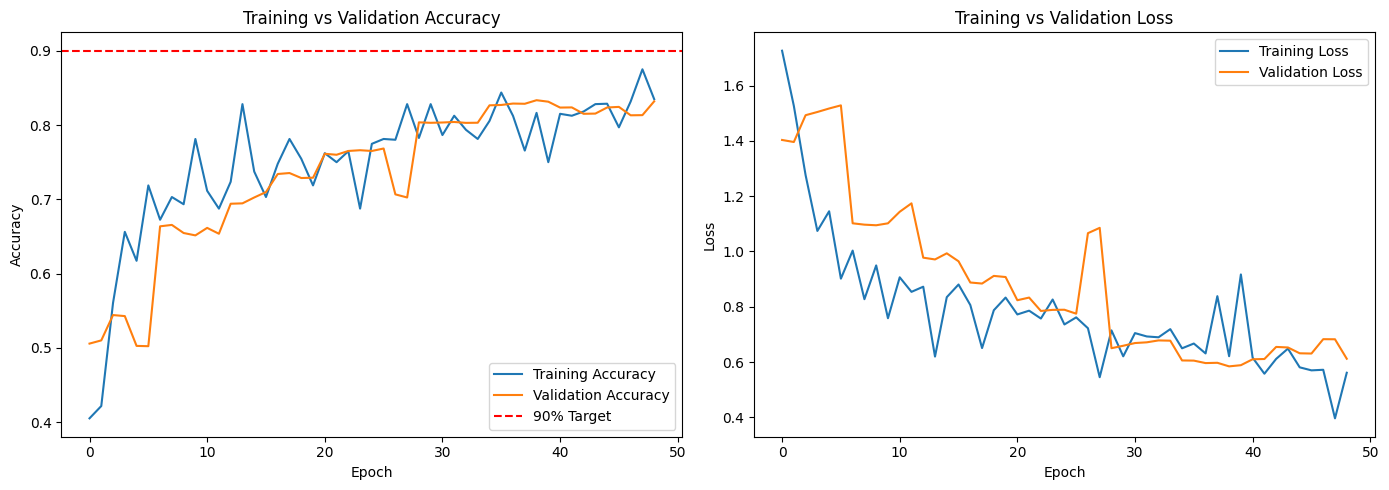

In [11]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.axhline(y=0.90, color='red', linestyle='--', label='90% Target')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Evaluation Metrics on the Test Set

In [12]:
y_pred_probs = tuned_model.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

if accuracy >= 0.90:
    print("\nTarget achieved: test accuracy is above 90%.")
else:
    print("\nBelow 90% target -- consider more epochs, stronger augmentation, or a wider network.")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Accuracy  : 0.8334
Precision : 0.8385
Recall    : 0.8334
F1-score  : 0.8307

Below 90% target -- consider more epochs, stronger augmentation, or a wider network.

Classification Report:

              precision    recall  f1-score   support

    airplane       0.83      0.86      0.85      1000
  automobile       0.87      0.97      0.92      1000
        bird       0.88      0.67      0.76      1000
         cat       0.79      0.63      0.70      1000
        deer       0.87      0.76      0.81      1000
         dog       0.79      0.77      0.78      1000
        frog       0.70      0.96      0.81      1000
       horse       0.90      0.87      0.88      1000
        ship       0.90      0.91      0.91      1000
       truck       0.86      0.93      0.90      1000

    accuracy                           0.83     10000
   macro avg       0.84      0.83      0.83     10000
weighted avg       0.84      0.83      0.83     10000



## Confusion Matrix

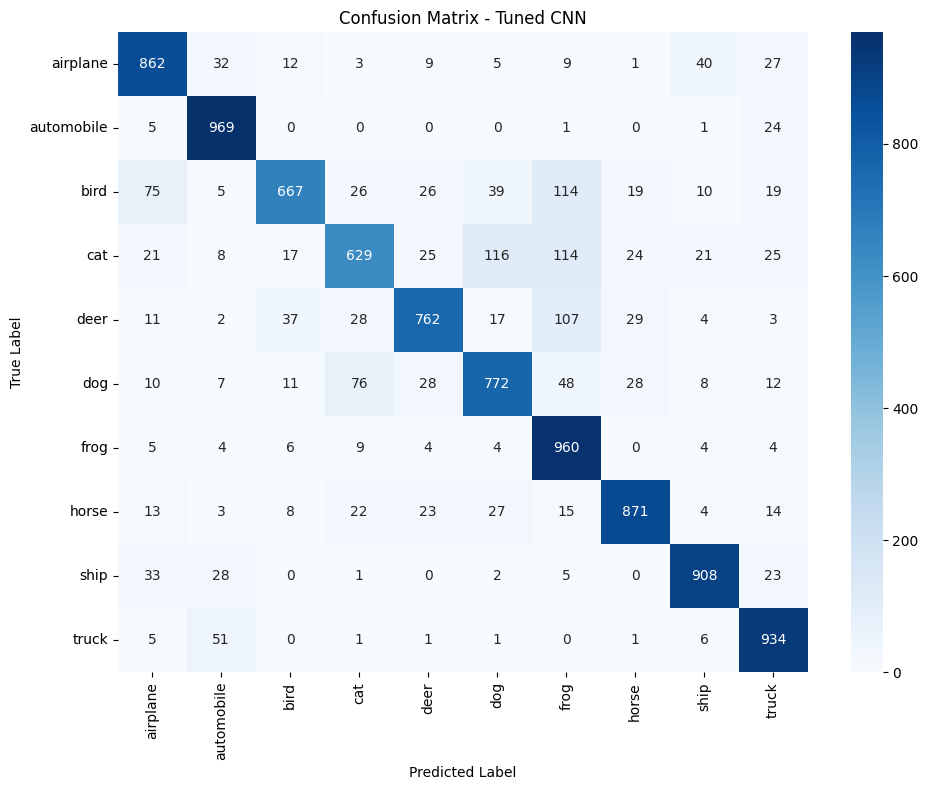

In [13]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Tuned CNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## Summary: Baseline vs Tuned Model
Fill in the baseline accuracy from `cifar10_cnn_experiment.ipynb` (Cell 13) to compare against the tuned model's result computed above.

In [14]:
summary_df = pd.DataFrame({
    'Model': ['Baseline CNN (no augmentation/regularization)', 'Tuned CNN (BatchNorm + Dropout + L2 + Augmentation)'],
    'Test Accuracy': [None, accuracy],  # fill in the baseline number from the original notebook
})
summary_df

,Model,Test Accuracy
0,Baseline CNN (no augmentation/regularization),NaN
1,Tuned CNN (BatchNorm + Dropout + L2 + Augmenta...,0.8334
